# 01. Distribution Fitting

## What You'll Learn

## Set Up

In [51]:
import pythonnet
pythonnet.load("netfx")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_donet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from RMC.BestFit import DataFrame, ExactData
from RMC.BestFit.Model import UnivariateDistribution
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod
from Numerics.Distributions import UnivariateDistributionType

## Probability Distributions to Compare

In [52]:
# Annual-maxima style dataset
annual_peaks = np.array([
    7420, 8010, 8350, 8680, 8920,
    9150, 9430, 9710, 9980, 10240,
    10610, 10980, 11320, 11740, 12110,
    12680, 13150, 13720, 14590, 15440,
    16680, 18120, 19750, 21430, 23680,
], dtype=float)

df = DataFrame()
for i, q in enumerate(annual_peaks):
    df.ExactSeries.Add(ExactData(1999 + i, float(q)))
df.PlottingParameter = 0.0
df.CalculatePlottingPositions()

mu = float(np.mean(annual_peaks))
sd = float(np.std(annual_peaks, ddof=1))

specs = {
    "Normal":    (UnivariateDistributionType.Normal,
                  [mu, sd]),
    "LogNormal": (UnivariateDistributionType.LogNormal,
                  [np.log(max(mu, 1.0)), 0.25]),
    "GEV":       (UnivariateDistributionType.GeneralizedExtremeValue,
                  [mu, 0.82 * sd, 0.10]),
    "Gumbel":    (UnivariateDistributionType.Gumbel,
                  [mu, 0.80 * sd]),
    "Gamma":     (UnivariateDistributionType.GammaDistribution,
                  [6.0, max(1.0, mu / 6.0)]),
    "Weibull":   (UnivariateDistributionType.Weibull,
                  [2.1, max(1.0, mu)]),
    "LP3":       (UnivariateDistributionType.LogPearsonTypeIII,
                  [np.log10(max(mu, 1.0)), 0.18, 0.10]),
}

### Fitting Using MLE

In [53]:
rows = []
fitted_models = {}

for name, (dtype, seed_params) in specs.items():
    model = UnivariateDistribution(df, dtype)

    model.Parameters[0].Value = seed_params[0]
    model.Parameters[1].Value = seed_params[1]
    
    mle = MaximumLikelihood(model)
    mle.Estimate()
    mle_params = np.array([float(v) for v in mle.BestParameterSet.Values], dtype=float)

    model.SetParameterValues(convert_to_donet_array(mle_params))

    fit = model.Distribution

    rows.append({
        "distribution": name,
        "mean": float(fit.Mean),
        "std": float(fit.StandardDeviation),
        "q90": float(fit.InverseCDF(0.90)),
        "q99": float(fit.InverseCDF(0.99)),
    })

    fitted_models[name] = model

summary = pd.DataFrame(rows)
summary

,distribution,mean,std,q90,q99
0,Normal,1.263560e+04,4.593594e+03,1.852253e+04,2.332190e+04
1,LogNormal,3.338910e+09,2.217410e+09,6.035049e+09,1.134854e+10
2,GEV,1.470540e+04,4.599488e+03,2.070625e+04,2.912859e+04
3,Gumbel,1.475680e+04,4.713211e+03,2.090542e+04,2.954057e+04
4,Gamma,1.326738e+04,2.821423e+02,1.363022e+04,1.393255e+04
5,Weibull,2.099909e+00,2.029858e-04,2.100132e+00,2.100242e+00
6,LP3,1.376889e+04,5.961256e+03,2.149215e+04,3.314145e+04


,T,Normal,LogNormal,GEV,Gumbel,Gamma,Weibull,LP3
0,2.0,12635.600000,2.781464e+09,13950.360237,13982.489265,13265.380054,2.099942,12635.381834
1,5.0,16501.666314,4.625930e+09,18015.443314,18147.692352,13504.234871,2.100075,17909.583698
2,10.0,18522.527681,6.035049e+09,20706.248310,20905.419221,13630.220313,2.100132,21492.154640
3,25.0,20677.541168,8.013617e+09,24105.365767,24389.814432,13765.427877,2.100185,26105.669515
4,50.0,22069.688832,9.624598e+09,26626.504737,26974.737847,13853.244747,2.100216,29600.210929
5,100.0,23321.897816,1.134854e+10,29128.589605,29540.574594,13932.551481,2.100242,33141.454968
6,200.0,24467.914233,1.319559e+10,31621.110465,32097.049034,14005.396338,2.100264,36752.543978


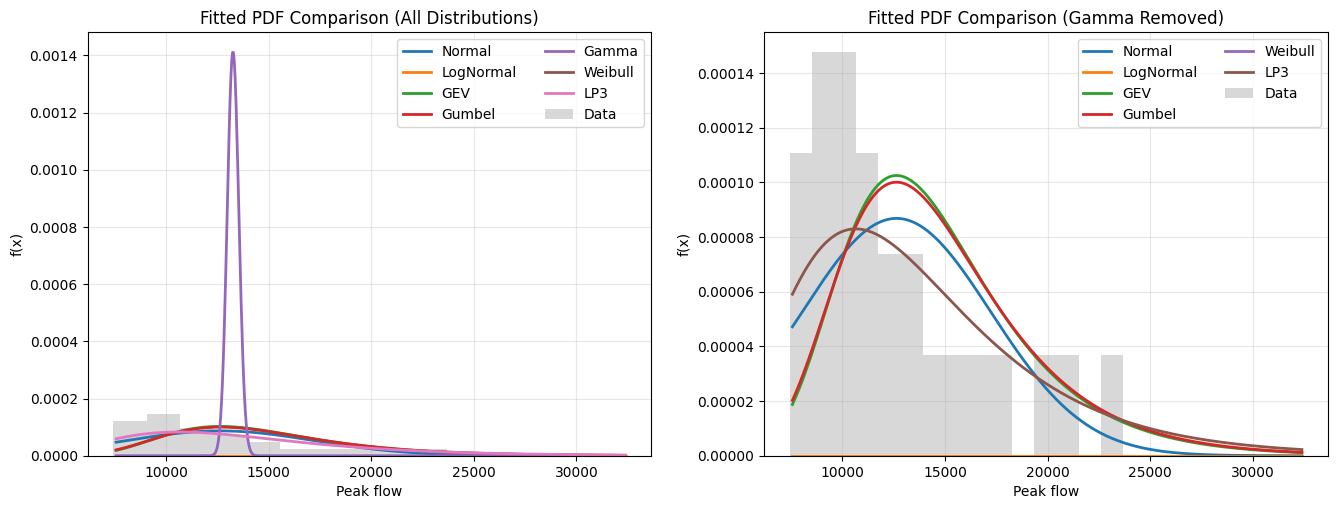

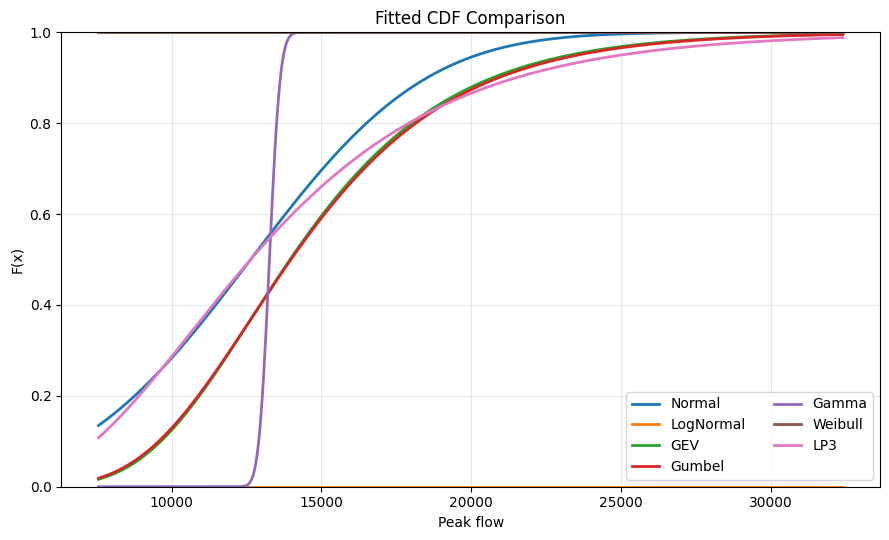

In [54]:
# Compare fitted CDF curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize= (16,5.5))

x = annual_peaks.copy()
xg = np.linspace(np.percentile(x, 1), np.percentile(x, 99) * 1.4, 600)

# First subplot: Full PDF comparison (all 7 distributions)
for name in ["Normal", "LogNormal", "GEV", "Gumbel", "Gamma", "Weibull", "LP3"]:
    m = fitted_models[name]
    y = np.array([float(m.Distribution.PDF(float(v))) for v in xg])
    ax1.plot(xg, y, lw=2, label=name)

ax1.hist(annual_peaks, density=True, alpha=0.3, color="gray", label="Data")
ax1.set_title("Fitted PDF Comparison (All Distributions)")
ax1.set_xlabel("Peak flow")
ax1.set_ylabel("f(x)")
ax1.grid(alpha=0.3)
ax1.legend(ncol=2)

# Second subplot: PDF comparison (Gamma removed)
for name in ["Normal", "LogNormal", "GEV", "Gumbel", "Weibull", "LP3"]:
    m = fitted_models[name]
    y = np.array([float(m.Distribution.PDF(float(v))) for v in xg])
    ax2.plot(xg, y, lw=2, label=name)

ax2.hist(annual_peaks, bins=15, density=True, alpha=0.3, color="gray", label="Data")
ax2.set_title("Fitted PDF Comparison (Gamma Removed)")
ax2.set_xlabel("Peak flow")
ax2.set_ylabel("f(x)")
ax2.grid(alpha=0.3)
ax2.legend(ncol=2)

plt.figure(figsize=(9, 5.5))
for name in ["Normal", "LogNormal", "GEV", "Gumbel", "Gamma", "Weibull", "LP3"]:
    m = fitted_models[name]
    y = np.array([float(m.Distribution.CDF(float(v))) for v in xg])
    plt.plot(xg, y, lw=2, label=name)

plt.title("Fitted CDF Comparison")
plt.xlabel("Peak flow")
plt.ylabel("F(x)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

# Return-period table from fitted models
T = np.array([2, 5, 10, 25, 50, 100, 200], dtype=float)
F = 1.0 - 1.0/T
rows = []
for t, f in zip(T, F):
    row = {"T": float(t)}
    for name, m in fitted_models.items():
        row[name] = float(m.Distribution.InverseCDF(float(f)))
    rows.append(row)

qtab = pd.DataFrame(rows)
display(qtab)

## Fitting Analysis

## Summary 

## Exercises